In [3]:
import pandas as pd
import geopandas as gpd
import folium
import requests
import itertools
from shapely.geometry import Polygon

# -------------------------
# 1) Vertiport table
# -------------------------
verts = pd.DataFrame({
    "name": [
        "Dallas CBD",
        "DFW Airport",
        "Dallas Love Field Airport",
        "Fort Worth City Center",
        "Mesquite Metro Airport",
        "Dallas Executive Airport (RBD)",
        "Denton Municipal Airport",
        "Fort Worth Meacham International Airport",
        "Arlington Municipal Airport",
        "McKinney National Airport"
    ],
    "lat": [
        32.7767, 32.8998, 32.84815, 32.75550, 32.7470,
        32.6810, 33.20083, 32.81969, 32.6639, 33.1753
    ],
    "lon": [
        -96.7970, -97.0409, -96.85135, -97.33080, -96.5304,
        -96.8690, -97.19778, -97.36319, -97.0943, -96.5825
    ]
})

verts_gdf = gpd.GeoDataFrame(
    verts,
    geometry=gpd.points_from_xy(verts["lon"], verts["lat"]),
    crs="EPSG:4326"
)
tracts = gpd.read_file("tl_2022_48_tract.shp").to_crs(epsg=4326)

AttributeError: module 'fiona' has no attribute 'path'

## EVTOL & Passenger arrival time distribution

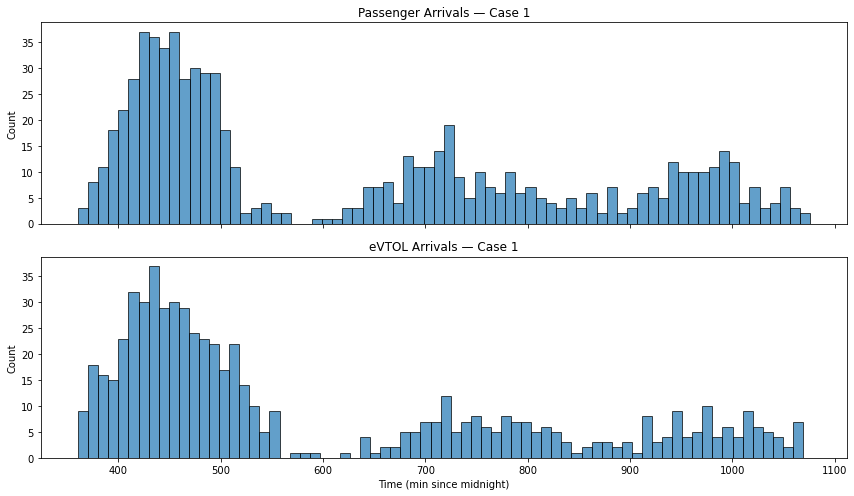


=== DFW Airport Scenario ===
Destination                    Dist(mi)   Fare($)   Share(%)
-------------------------------------------------------------
Dallas CBD                         16.5     69.55      25.0
Dallas Love Field Airport          11.6     54.69       7.9
Fort Worth City Center             19.6     78.69      20.0
Mesquite Metro Airport             31.5    114.40       7.9
Dallas Executive Airport (RBD)     18.1     74.35       7.9
Denton Municipal Airport           22.7     88.09       7.9
Fort Worth Meacham International Airport     19.5     78.52       7.9
Arlington Municipal Airport        16.6     69.78       7.9
McKinney National Airport          32.7    118.01       7.9


In [14]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import folium
import math

# eVTOL Stochastic Scheduling - Global Configuration

# Simulation Settings
BASE_PRICE = 0.1482   # Average residential electricity rate in Dallas (PowerChoiceTexas.org, 2025)
M_PEAK = 1.5          # CoServ TOU Rate Sheet: Peak ≈ 20.92¢/kWh
M_SHOULDER = 1.05     # Shoulder multiplier (transitional pricing)
M_OFF = 0.6           # CoServ TOU Rate Sheet: Off-peak ≈ 8.56¢/kWh
# Reference: https://www.powerchoicetexas.org/cities/dallas-electricity-rates , https://www.coserv.com/service/residential/residential-rates/

# eVTOL and Battery Parameters
SOC_MIN = 70.0                      # Minimum required state of charge (%)
BATTERY_CAPACITY = 150.0            # Battery capacity in kWh
CHARGING_RATE = 125                 # Charging power in kW
EVTOL_CAPACITY = 4                  # Maximum passengers per eVTOL
# Reference: Z. Wu, Y. Zhang, Optimal eVTOL charging and passenger scheduling, AIAA Aviation 2020 Forum, 2020.

# Scenario Generation Parameters
N_SCENARIOS = 30                    # Number of demand scenarios generated
TARGET_SCENARIOS = 3                # Number of reduced representative scenarios
HORIZON_START = 360   # 6AM
HORIZON_END = 1080    # 6PM
HORIZON_MINUTES = HORIZON_END - HORIZON_START              # 12-hour simulation horizon (720 minutes)
BIN_SIZE = 10                       # Each time bin equals 10 minutes
L_PERIODS = HORIZON_MINUTES // BIN_SIZE   # 72 periods (12h × 60 / 10)

# Model Parameters
M_FACILITIES = 3                    # Number of charging facilities
LOS = 2                             # Level of Service: maximum waiting time (2 periods = 20 min)

# Randomization Control
SEED = 60                           # Random seed for reproducibility

# Case selection: 1 = Dallas CBD, 2 = DFW Airport
FIXED_CASE = 2

# Vertiport Network Definition (Hub + 9 Destinations)
vertiports = {
    'Dallas CBD': (32.7767, -96.7970),
    'DFW Airport': (32.8998, -97.0409),
    'Dallas Love Field Airport': (32.84815, -96.85135),
    'Fort Worth City Center': (32.75550, -97.33080),
    'Mesquite Metro Airport': (32.7470, -96.5304),
    'Dallas Executive Airport (RBD)': (32.6810, -96.8690),
    'Denton Municipal Airport': (33.20083, -97.19778),
    'Fort Worth Meacham International Airport': (32.81969, -97.36319),
    'Arlington Municipal Airport': (32.6639, -97.0943),
    'McKinney National Airport': (33.1753, -96.5825)
}

# Haversine Function to Calculate Distance in Miles
def haversine_miles(lat1, lon1, lat2, lon2):
    """Compute great-circle distance between two coordinates in miles."""
    R = 3958.8
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2)**2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))

def run_scenario(hub_name, assignment_case, plot=True, verbose=True):
    """Run an eVTOL demand scenario for a given hub (Dallas CBD or DFW Airport)."""
    hub_coord = vertiports[hub_name]
    DESTINATION_DATA = {}

    # ============================================================
    #  Distance and Fare Setup
    # ============================================================
    for name, coord in vertiports.items():
        if name == hub_name:
            continue
        dist = haversine_miles(hub_coord[0], hub_coord[1], coord[0], coord[1])
        fare = round(20 + 3 * dist, 2)
        DESTINATION_DATA[name] = {'distance': dist, 'fare': fare}

    # ============================================================
    #  Assignment Logic (depends on hub)
    # ============================================================
    if assignment_case == 1:
        assignment = {'DFW Airport': 0.25, 'Fort Worth City Center': 0.20}
    elif assignment_case == 2:
        assignment = {'Dallas CBD': 0.25, 'Fort Worth City Center': 0.20}
    else:
        raise ValueError("assignment_case must be 1 (Dallas CBD) or 2 (DFW Airport)")

    remaining = [k for k in DESTINATION_DATA.keys() if k not in assignment]
    leftover = max(0.0, 1.0 - sum(assignment.values()))
    for k in remaining:
        assignment[k] = leftover / len(remaining)

    # ============================================================
    #  Passenger & eVTOL Arrival Distributions
    # ============================================================
    if assignment_case == 1:  # Dallas CBD (morning demand)
        passenger_arrivals = np.concatenate([
            np.random.normal(7.5 * 60, 40, 400),
            np.random.normal(12.0 * 60, 60, 180),
            np.random.normal(16.0 * 60, 70, 160)
        ])
        evtol_arrivals = np.concatenate([
            np.random.normal(7.0 * 60, 45, 220),
            np.random.normal(8.0 * 60, 40, 220),
            np.random.normal(12.5 * 60, 60, 120),
            np.random.normal(16.5 * 60, 70, 120)
        ])
    elif assignment_case == 2:  # DFW Airport (evening demand)
        passenger_arrivals = np.concatenate([
            np.random.normal(8.0 * 60, 50, 200),
            np.random.normal(13.0 * 60, 60, 180),
            np.random.normal(19.5 * 60, 40, 420)
        ])
        evtol_arrivals = np.concatenate([
            np.random.normal(7.5 * 60, 50, 190),
            np.random.normal(12.5 * 60, 55, 190),
            np.random.normal(19.0 * 60, 45, 400)
        ])

    # Clip to 6AM–6PM window
    passenger_arrivals = passenger_arrivals[
        (passenger_arrivals >= HORIZON_START) & (passenger_arrivals < HORIZON_END)
    ]
    evtol_arrivals = evtol_arrivals[
        (evtol_arrivals >= HORIZON_START) & (evtol_arrivals < HORIZON_END)
    ]

    # ============================================================
    #  Scenario Summary Output (only if verbose=True)
    # ============================================================
    if verbose:
        print(f"\n=== {hub_name} Scenario ===")
        print("Destination                    Dist(mi)   Fare($)   Share(%)")
        print("-------------------------------------------------------------")
        for name, data in DESTINATION_DATA.items():
            share = assignment[name] * 100
            print(f"{name:<30} {data['distance']:>8.1f} {data['fare']:>9.2f} {share:>9.1f}")

    # ============================================================
    #  Visualization (only if plot=True)
    # ============================================================
    if plot:
        fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
        axs[0].hist(passenger_arrivals, bins=L_PERIODS, alpha=0.7, edgecolor='black')
        axs[0].set_title(f"Passenger Arrivals — Case {assignment_case}")
        axs[0].set_ylabel("Count")

        axs[1].hist(evtol_arrivals, bins=L_PERIODS, alpha=0.7, edgecolor='black')
        axs[1].set_title(f"eVTOL Arrivals — Case {assignment_case}")
        axs[1].set_xlabel("Time (min since midnight)")
        axs[1].set_ylabel("Count")

        plt.tight_layout()
        plt.show()

    # ============================================================
    #  Map Visualization
    # ============================================================
    m = folium.Map(location=hub_coord, zoom_start=9)
    for name, coord in vertiports.items():
        color = 'red' if name == hub_name else 'blue'
        folium.CircleMarker(location=coord, radius=8, popup=name,
                            color=color, fill=True, fill_color=color).add_to(m)
    for name, coord in vertiports.items():
        if name == hub_name:
            continue
        folium.PolyLine([hub_coord, coord], color='black',
                        tooltip=f"{name}: {DESTINATION_DATA[name]['distance']:.1f} mi | ${DESTINATION_DATA[name]['fare']:.0f}").add_to(m)

    # ============================================================
    #  Destination Numbering
    # ============================================================
    destination_map = {i + 1: name for i, name in enumerate(DESTINATION_DATA.keys())}
    name_to_number = {name: i + 1 for i, name in enumerate(DESTINATION_DATA.keys())}

    # ============================================================
    #  Return Results
    # ============================================================
    return {
        "hub": hub_name,
        "assignment_case": assignment_case,
        "destinations": DESTINATION_DATA,
        "assignment_shares": assignment,
        "passenger_arrivals": passenger_arrivals,
        "evtol_arrivals": evtol_arrivals,
        "destination_map": destination_map,
        "name_to_number": name_to_number,
        "map": m
    }

result1 = run_scenario('Dallas CBD', 1, plot=True, verbose=False)
result2 = run_scenario('DFW Airport', 2, plot=False, verbose=True)
m1 = result1['map']
m2 = result2['map']



In [15]:
# ============================================================
#  Energy Price Function
# ============================================================
def energy_price_per_kWh(t, base=BASE_PRICE, m_peak=M_PEAK,
                         m_shoulder=M_SHOULDER, m_off=M_OFF):
    """Time-of-Use (TOU) pricing function. t in [0,24). Returns $/kWh."""
    if not (0 <= t < 24):
        raise ValueError("t must be in [0,24)")
    if 16 <= t < 21:                      # 4–9 pm
        return base * m_peak
    elif 0 <= t < 6 or 21 <= t < 24:      # midnight–6 am, 9 pm–midnight
        return base * m_off
    else:                                 # shoulder
        return base * m_shoulder

# ============================================================
#  eVTOL & Passenger Simulation (6 AM–6 PM, Assignment-Aware)
# ============================================================
def simulate_evtol_and_passengers(
    scenario_data,  # <- the dictionary returned by run_scenario()
    soc_min=SOC_MIN,
    battery_capacity=BATTERY_CAPACITY,
    charging_rate=CHARGING_RATE,
    plot=True
):
    """Simulate eVTOL charging and passenger assignment for the given fixed case."""

    # Extract from scenario
    assignment_case = scenario_data["assignment_case"]
    destination_data = scenario_data["destinations"]
    assignment = scenario_data["assignment_shares"]
    passenger_arrivals = scenario_data["passenger_arrivals"]
    evtol_arrivals = scenario_data["evtol_arrivals"]

    np.random.seed(SEED)
    random.seed(SEED)

    # ---- Initial SoC ----
    SoC = {j: random.uniform(20, 60) for j in range(len(evtol_arrivals))}

    # ---- Charging simulation ----
    charging_cost, charging_periods, finish_period = {}, {}, {}
    for j, arrival_min in enumerate(evtol_arrivals):
        if SoC[j] < soc_min:
            charge_needed = battery_capacity * ((soc_min - SoC[j]) / 100.0)
            hours_to_charge = charge_needed / charging_rate
            periods_to_charge = int(hours_to_charge * 6) + 1
            charging_periods[j] = periods_to_charge

            total_cost = 0.0
            current_time_min = arrival_min
            remaining_periods = periods_to_charge
            while remaining_periods > 0 and current_time_min < HORIZON_END:
                price = energy_price_per_kWh(current_time_min / 60.0)
                energy_this_period = charging_rate / 6
                total_cost += energy_this_period * price
                current_time_min += 10
                remaining_periods -= 1

            charging_cost[j] = total_cost
            finish_period[j] = current_time_min
        else:
            charging_periods[j] = 0
            finish_period[j] = arrival_min
            charging_cost[j] = 0.0

    # ---- Passenger destination assignment ----
    dest_names = list(assignment.keys())
    weights = np.array(list(assignment.values()))
    weights /= weights.sum()

    destination_of_passenger = {
        pid: np.random.choice(dest_names, p=weights)
        for pid in range(len(passenger_arrivals))
    }

    fare_of_passenger = {
        pid: destination_data[destination_of_passenger[pid]]["fare"]
        for pid in range(len(passenger_arrivals))
    }

    # ---- Optional visualization ----
    if plot:
        fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        axs[0].hist(passenger_arrivals, bins=L_PERIODS, alpha=0.7, edgecolor='black')
        axs[0].set_ylabel("Passenger Count")
        axs[0].set_title(f"Passenger Arrivals [Case {assignment_case}] (6 AM–6 PM)")
        axs[0].grid(True, alpha=0.3)

        axs[1].hist(evtol_arrivals, bins=L_PERIODS, alpha=0.7, edgecolor='black')
        axs[1].set_xlabel("Time (min since midnight)")
        axs[1].set_ylabel("eVTOL Count")
        axs[1].set_title(f"eVTOL Arrivals [Case {assignment_case}] (6 AM–6 PM)")
        axs[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # ---- Return results ----
    return {
        "assignment_case": assignment_case,
        "SoC": SoC,
        "charging_periods": charging_periods,
        "finish_charging": finish_period,
        "charging_cost": charging_cost,
        "destinations": destination_of_passenger,
        "fares": fare_of_passenger,
    }


# ============================================================
#  Build Per-Bin Destination PMFs (Assignment-Aware)
# ============================================================
from collections import Counter

def build_bin_destination_pmfs(passenger_arrivals,
                               passenger_dest_names,
                               assignment_shares,
                               start_min=HORIZON_START,
                               end_min=HORIZON_END,
                               bin_size=BIN_SIZE,
                               alpha=1.0,
                               blend_weight=0.15):
    """Build per-bin categorical PMFs over destinations (smoothed)."""
    l_periods = (end_min - start_min) // bin_size
    bin_idx = np.clip(((passenger_arrivals - start_min) // bin_size).astype(int), 0, l_periods - 1)

    per_bin_counts = [Counter() for _ in range(l_periods)]
    all_dests = set()
    for pid, b in enumerate(bin_idx):
        dname = passenger_dest_names[pid]
        per_bin_counts[b][dname] += 1
        all_dests.add(dname)

    global_counts = Counter(passenger_dest_names.values())
    total_global = sum(global_counts.values())
    global_p = {d: (global_counts[d] / total_global) if total_global > 0 else 0.0 for d in all_dests}

    total_assign = sum(assignment_shares.values())
    p_target = {d: assignment_shares.get(d, 0.0) / total_assign for d in all_dests}

    pmfs = []
    for t in range(l_periods):
        counts = per_bin_counts[t]
        total = sum(counts.values())

        pmf = {}
        for d in all_dests:
            prior = global_p.get(d, 1.0 / len(all_dests))
            pmf[d] = (counts.get(d, 0) + alpha * prior) / (total + alpha)

        if blend_weight > 0:
            for d in pmf:
                pmf[d] = (1 - blend_weight) * pmf[d] + blend_weight * p_target.get(d, 0.0)

        s = sum(pmf.values()) or 1e-9
        for d in pmf:
            pmf[d] /= s

        pmfs.append(pmf)

    return pmfs, sorted(all_dests)

In [16]:
# ============================================================
#  Main Execution
# ============================================================
if __name__ == "__main__":
    """
    Entry point for the eVTOL simulation pipeline.
    Runs the fixed scenario (Case 1 or Case 2) end-to-end:
        1. Generate the vertiport scenario (map, fares, assignments)
        2. Simulate eVTOLs and passenger activity
        3. Analyze passenger destination distributions
        4. Build destination PMFs per time bin
        5. Display summarized outputs
    """

    # ------------------------------------------------------------
    #  Choose the active scenario
    # ------------------------------------------------------------
    HUB_NAME = 'Dallas CBD' if FIXED_CASE == 1 else 'DFW Airport'

    print("\n==========================")
    print(f"Running FIXED CASE {FIXED_CASE}: {HUB_NAME} Hub")
    print("==========================")

    # ------------------------------------------------------------
    #  Generate Scenario (map, assignments, distributions)
    # ------------------------------------------------------------
    scenario = run_scenario(HUB_NAME, FIXED_CASE, plot=False, verbose=False)

    # ------------------------------------------------------------
    #  Simulate eVTOL and Passenger Operations
    # ------------------------------------------------------------
    results = simulate_evtol_and_passengers(
        scenario_data=scenario,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        plot=False
    )

    # ------------------------------------------------------------
    #  Passenger Distribution Summary
    # ------------------------------------------------------------
    from collections import Counter

    dest_count = Counter(results["destinations"].values())
    total_passengers = len(results["destinations"])

    print("\n" + "=" * 70)
    print(f"PASSENGER DESTINATION DISTRIBUTION — {HUB_NAME}")
    print("=" * 70)
    for dest, count in dest_count.items():
        pct = (count / total_passengers) * 100
        print(f"{dest:<40} {count:5d} passengers ({pct:5.1f}%)")
    print("=" * 70)

    # ------------------------------------------------------------
    #  Build PMFs (Destination Probability per Time Bin)
    # ------------------------------------------------------------
    pmfs, dests = build_bin_destination_pmfs(
        scenario["passenger_arrivals"],
        results["destinations"],
        scenario["assignment_shares"]
    )

    print("\n✅ PMFs successfully built for case "
          f"{FIXED_CASE} ({HUB_NAME}).\n")

    # ------------------------------------------------------------
    #  Simulation Summary (Partial Display)
    # ------------------------------------------------------------
    print("\n" + "=" * 70)
    print("SIMULATION SUMMARY")
    print("=" * 70)
    print(f"Passengers generated: {len(results['destinations'])}")
    print(f"eVTOLs generated: {len(results['SoC'])}")
    print("\n")

    print("eVTOL SoC and Charging Details (first 25):")
    for i, (soc, periods, cost) in enumerate(
        zip(results['SoC'].values(),
            results['charging_periods'].values(),
            results['charging_cost'].values())
    ):
        if i >= 25:
            break
        print(f"eVTOL {i:>2}: SoC={soc:5.1f}%, ChargePeriods={periods:>2}, Cost=${cost:5.2f}")

    print("\nPassenger Destinations & Fares (first 25):")
    dest_names = list(results["destinations"].values())
    fares = list(results["fares"].values())
    for i in range(min(25, len(dest_names))):
        dnum = scenario["name_to_number"][dest_names[i]]
        print(f"Passenger {i:>2}: Destination {dnum:>2} ({dest_names[i]:<30}) Fare=${fares[i]:6.2f}")

    print("=" * 70)



Running FIXED CASE 2: DFW Airport Hub

PASSENGER DESTINATION DISTRIBUTION — DFW Airport
Fort Worth City Center                      77 passengers ( 20.2%)
Dallas CBD                                 109 passengers ( 28.5%)
Dallas Executive Airport (RBD)              26 passengers (  6.8%)
Mesquite Metro Airport                      28 passengers (  7.3%)
Denton Municipal Airport                    30 passengers (  7.9%)
Arlington Municipal Airport                 16 passengers (  4.2%)
McKinney National Airport                   30 passengers (  7.9%)
Dallas Love Field Airport                   38 passengers (  9.9%)
Fort Worth Meacham International Airport    28 passengers (  7.3%)

✅ PMFs successfully built for case 2 (DFW Airport).


SIMULATION SUMMARY
Passengers generated: 382
eVTOLs generated: 417


eVTOL SoC and Charging Details (first 25):
eVTOL  0: SoC= 32.3%, ChargePeriods= 3, Cost=$ 9.73
eVTOL  1: SoC= 43.1%, ChargePeriods= 2, Cost=$ 6.48
eVTOL  2: SoC= 30.6%, ChargePeriods= 

## Joint Demand Scenario Generation with NHPP

In [ ]:
# Joint Demand Scenario Generator (NHPP + Bin PMFs)
def generate_joint_demand_scenarios(passenger_arrivals,
                                    evtol_arrivals,
                                    destination_data,
                                    bin_pmfs,
                                    n_scenarios=N_SCENARIOS,
                                    horizon_minutes=HORIZON_MINUTES,
                                    bin_size=BIN_SIZE,
                                    plot=True):
    """
    Generate multiple joint demand scenarios for passenger arrivals,
    eVTOL availability, and destination distributions using a 
    Nonhomogeneous Poisson Process (NHPP) framework.

    Parameters
    ----------
    passenger_arrivals : array-like
        Baseline passenger arrival times (in minutes).
    evtol_arrivals : array-like
        Baseline eVTOL arrival times (in minutes).
    destination_data : dict
        Dictionary containing destination attributes (distance, fare, etc.).
    bin_pmfs : list of dict
        Per-bin categorical probability mass functions (PMFs) over destinations.
    n_scenarios : int
        Number of stochastic scenarios to generate.
    horizon_minutes : int
        Total simulation horizon in minutes.
    bin_size : int
        Time resolution per bin (default = 10 minutes).
    plot : bool
        Whether to visualize baseline rate curves.

    Returns
    -------
    scenarios : list of dict
        A list of scenario dictionaries, each containing:
            - a_t : simulated passenger arrivals per bin
            - e_t : simulated eVTOL arrivals per bin
            - total_passengers : total passengers in scenario
            - total_evtols : total eVTOLs in scenario
            - destination_counts : per-destination passenger count
            - passenger_destinations : passenger → destination mapping
            - passenger_fares : passenger → fare mapping
    """

    # ------------------------------------------------------------
    # 1. Define Time Discretization
    # ------------------------------------------------------------
    start_min, end_min = HORIZON_START, HORIZON_END
    l_periods = (end_min - start_min) // bin_size
    bin_edges = np.linspace(start_min, end_min, l_periods + 1)
    time_periods = np.arange(1, l_periods + 1)

    # ------------------------------------------------------------
    # 2. Build Baseline Histograms and Smooth Arrival Rates
    # ------------------------------------------------------------
    # Count baseline arrivals per bin
    passenger_hist, _ = np.histogram(passenger_arrivals, bins=bin_edges)
    evtol_hist, _ = np.histogram(evtol_arrivals, bins=bin_edges)

    # Smooth baseline rates using Gaussian filter
    f_a = gaussian_filter1d(passenger_hist.astype(float), sigma=2)
    f_e = gaussian_filter1d(evtol_hist.astype(float), sigma=2)

    # Compute residual variance for stochastic noise estimation
    residuals_a = passenger_hist - f_a
    residuals_e = evtol_hist - f_e
    sigma_epsilon_sq = min(np.var(residuals_a), np.var(residuals_e))

    # ------------------------------------------------------------
    # 3. Generate Multiple NHPP-Based Scenarios
    # ------------------------------------------------------------
    scenarios = []
    for scenario_id in range(n_scenarios):

        # Add Gaussian noise to create stochastic rate realizations
        epsilon_t = np.random.normal(0, np.sqrt(sigma_epsilon_sq), l_periods)

        # Ensure rates remain nonnegative
        lambda_a_omega = np.maximum(f_a + epsilon_t, 0)
        lambda_e_omega = np.maximum(f_e + epsilon_t, 0)

        # Sample arrivals per bin using Poisson draws
        a_t_omega = np.random.poisson(lambda_a_omega)
        e_t_omega = np.random.poisson(lambda_e_omega)

        # --------------------------------------------------------
        # 4. Destination Sampling for Each Passenger Arrival Bin
        # --------------------------------------------------------
        passenger_destinations, passenger_fares = {}, {}
        pid = 0

        for t in range(l_periods):
            n = int(a_t_omega[t])
            if n <= 0:
                continue

            # Get PMF for this time bin
            pmf = bin_pmfs[t]
            dnames = list(pmf.keys())
            probs = np.array([pmf[d] for d in dnames], dtype=float)
            probs /= probs.sum() if probs.sum() > 0 else 1.0

            # Sample destinations according to bin PMF
            choices = np.random.choice(dnames, size=n, p=probs)
            for dname in choices:
                passenger_destinations[pid] = dname
                passenger_fares[pid] = destination_data[dname]["fare"]
                pid += 1

        # Summarize destination counts for this scenario
        dest_counts = Counter(passenger_destinations.values())

        # Store all scenario data
        scenarios.append({
            "id": scenario_id,
            "a_t": a_t_omega,
            "e_t": e_t_omega,
            "total_passengers": int(np.sum(a_t_omega)),
            "total_evtols": int(np.sum(e_t_omega)),
            "destination_counts": dict(dest_counts),
            "passenger_destinations": passenger_destinations,
            "passenger_fares": passenger_fares
        })

    # ------------------------------------------------------------
    # 5. Optional Visualization of Smoothed Baseline Rates
    # ------------------------------------------------------------
    if plot:
        plt.figure(figsize=(12, 5))
        plt.plot(time_periods, f_a, "o-", label="Baseline Passenger Rate")
        plt.plot(time_periods, f_e, "s-", label="Baseline eVTOL Rate")
        plt.title("Baseline Arrival Rates (Smoothed, 240–480 min)")
        plt.xlabel("Time Period (10-min bins)")
        plt.ylabel("Expected Arrivals per Bin")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return scenarios

In [18]:
# ============================================================
# 🧭 Main Execution — Minimal eVTOL Simulation Pipeline
# ============================================================
if __name__ == "__main__":
    """
    Full eVTOL simulation pipeline (clean version):
        1. Generate base vertiport scenario
        2. Simulate eVTOLs and passenger activity
        3. Build destination PMFs per time bin
        4. Generate 30 NHPP-based stochastic demand scenarios
        5. Display concise summary of first scenario
    """

    # ------------------------------------------------------------
    #  Scenario Selection
    # ------------------------------------------------------------
    HUB_NAME = 'Dallas CBD' if FIXED_CASE == 1 else 'DFW Airport'

    print("\n==========================")
    print(f"Running FIXED CASE {FIXED_CASE}: {HUB_NAME} Hub")
    print("==========================")

    # ------------------------------------------------------------
    #  Step 1: Scenario Generation
    # ------------------------------------------------------------
    scenario = run_scenario(HUB_NAME, FIXED_CASE, plot=False, verbose=False)

    # ------------------------------------------------------------
    #  Step 2: eVTOL and Passenger Simulation
    # ------------------------------------------------------------
    results = simulate_evtol_and_passengers(
        scenario_data=scenario,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        plot=False
    )

    # ------------------------------------------------------------
    #  Step 3: Build PMFs (Destination Probability per Time Bin)
    # ------------------------------------------------------------
    pmfs, dests = build_bin_destination_pmfs(
        scenario["passenger_arrivals"],
        results["destinations"],
        scenario["assignment_shares"]
    )

    # ------------------------------------------------------------
    #  Step 4: Generate 30 Stochastic Demand Scenarios (NHPP)
    # ------------------------------------------------------------
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=scenario["passenger_arrivals"],
        evtol_arrivals=scenario["evtol_arrivals"],
        destination_data=scenario["destinations"],
        bin_pmfs=pmfs,
        n_scenarios=N_SCENARIOS,     # 30 total
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False                   # clean, no plots
    )

    # ------------------------------------------------------------
    #  Step 5: Summary of First Scenario
    # ------------------------------------------------------------
    first = scenarios[0]
    print("\n--- Scenario 0 Summary ---")
    print(f"Total Passengers: {first['total_passengers']}")
    print(f"Total eVTOLs:     {first['total_evtols']}")
    print("Destination Breakdown:")
    for dest, count in first["destination_counts"].items():
        dnum = scenario["name_to_number"][dest]
        print(f"  Destination {dnum:>2}: {dest:<30} {count:>5d}")

    print("\n✅ Completed pipeline for Case "
          f"{FIXED_CASE} ({HUB_NAME}) with {len(scenarios)} scenarios.\n")



Running FIXED CASE 2: DFW Airport Hub



--- Scenario 0 Summary ---
Total Passengers: 381
Total eVTOLs:     440
Destination Breakdown:
  Destination  3: Fort Worth City Center            86
  Destination  2: Dallas Love Field Airport         38
  Destination  4: Mesquite Metro Airport            33
  Destination  9: McKinney National Airport         36
  Destination  1: Dallas CBD                        90
  Destination  6: Denton Municipal Airport          30
  Destination  8: Arlington Municipal Airport       18
  Destination  7: Fort Worth Meacham International Airport    21
  Destination  5: Dallas Executive Airport (RBD)    29

✅ Completed pipeline for Case 2 (DFW Airport) with 30 scenarios.



## Scenario Reduction via Backward Selection


In [19]:
# ============================================================
#  Scenario Reduction with eVTOL Filtering (Backward Selection)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Backward Scenario Reduction with eVTOL Constraint
# ------------------------------------------------------------
def scenario_reduction_backward_with_evtol_filter(
        scenarios,
        target_size=TARGET_SCENARIOS,
        plot=True):
    """
    Perform backward scenario reduction while ensuring that
    all selected scenarios contain at least one eVTOL event.

    This algorithm maintains scenario diversity using a
    pairwise Euclidean distance metric over feature vectors
    (combined passenger and eVTOL time series), while
    eliminating the least representative scenarios iteratively.

    Parameters
    ----------
    scenarios : list of dict
        Full set of generated scenarios from
        `generate_joint_demand_scenarios()`.
    target_size : int, default=TARGET_SCENARIOS
        Desired number of representative (reduced) scenarios.
    plot : bool, default=True
        Whether to visualize reduction results (optional diagnostics).

    Returns
    -------
    reduced_scenarios : list of dict
        Reduced scenario set with:
            - normalized probabilities
            - preserved diversity in time profiles
            - no scenarios with zero eVTOL presence
    """

    # ------------------------------------------------------------
    # 1. Filter Scenarios: Ensure at least one eVTOL present
    # ------------------------------------------------------------
    scenarios_with_evtols = [s for s in scenarios if s['total_evtols'] > 0]

    # If fewer valid scenarios than target, keep top by eVTOL count
    if len(scenarios_with_evtols) < target_size:
        scenarios_sorted = sorted(scenarios, key=lambda x: x['total_evtols'], reverse=True)
        scenarios_with_evtols = scenarios_sorted[:target_size]

    # ------------------------------------------------------------
    # 2. Initialize Probabilities & Feature Vectors
    # ------------------------------------------------------------
    n_original = len(scenarios_with_evtols)

    for scenario in scenarios_with_evtols:
        # Assign uniform initial probability
        scenario['probability'] = 1.0 / n_original
        # Build concatenated feature vector of passenger + eVTOL time series
        scenario['feature_vector'] = np.concatenate([scenario['a_t'], scenario['e_t']])

    # Working copy for iterative reduction
    working_scenarios = scenarios_with_evtols.copy()

    # ------------------------------------------------------------
    # 3. Backward Reduction Loop
    # ------------------------------------------------------------
    while len(working_scenarios) > target_size:
        n_current = len(working_scenarios)
        distances = np.zeros((n_current, n_current))

        # Compute pairwise Euclidean distances among all scenario vectors
        for i in range(n_current):
            for j in range(i + 1, n_current):
                dist = np.linalg.norm(
                    working_scenarios[i]['feature_vector'] -
                    working_scenarios[j]['feature_vector']
                )
                distances[i, j] = distances[j, i] = dist

        # Identify scenario with smallest “cost” (least representative)
        min_cost, remove_idx, nearest_neighbor = float('inf'), None, None
        for i in range(n_current):
            mask = np.ones(n_current, dtype=bool)
            mask[i] = False
            min_dist = np.min(distances[i, mask])
            cost = working_scenarios[i]['probability'] * min_dist

            if cost < min_cost:
                min_cost = cost
                remove_idx = i
                nearest_neighbor = np.argmin([
                    distances[i, j] if j != i else float('inf')
                    for j in range(n_current)
                ])

        # Transfer probability to nearest scenario, then remove weakest one
        working_scenarios[nearest_neighbor]['probability'] += \
            working_scenarios[remove_idx]['probability']
        _ = working_scenarios.pop(remove_idx)

    # ------------------------------------------------------------
    # 4. Normalize Final Probabilities
    # ------------------------------------------------------------
    total_prob = sum(s['probability'] for s in working_scenarios)
    for s in working_scenarios:
        s['probability'] /= total_prob

    # ------------------------------------------------------------
    # 5. Visualization (Optional)
    # ------------------------------------------------------------
    if plot:
        l_periods = len(scenarios[0]['a_t'])
        time_periods = np.arange(1, l_periods + 1)
        colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle("Reduced Scenario Set Analysis", fontsize=16, fontweight="bold")

        # (a) Passenger arrival comparison
        for i, s in enumerate(working_scenarios):
            axes[0, 0].plot(time_periods, s['a_t'], 'o-',
                            label=f"Scenario {s['id']+1} (p={s['probability']:.2f})",
                            color=colors[i % len(colors)], linewidth=2)
        axes[0, 0].set_title("Passenger Arrivals per Time Period")
        axes[0, 0].set_xlabel("Time Period (10-min bins)")
        axes[0, 0].set_ylabel("Passenger Count")
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # (b) eVTOL arrival comparison
        for i, s in enumerate(working_scenarios):
            axes[0, 1].plot(time_periods, s['e_t'], 's-',
                            label=f"Scenario {s['id']+1} (p={s['probability']:.2f})",
                            color=colors[i % len(colors)], linewidth=2)
        axes[0, 1].set_title("eVTOL Arrivals per Time Period")
        axes[0, 1].set_xlabel("Time Period (10-min bins)")
        axes[0, 1].set_ylabel("eVTOL Count")
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # (c) Scenario probabilities visualization
        labels = [f"Scenario {s['id']+1}" for s in working_scenarios]
        probs = [s['probability'] for s in working_scenarios]
        bars = axes[1, 0].bar(labels, probs,
                              color=colors[:len(working_scenarios)], alpha=0.7)
        axes[1, 0].set_title("Scenario Probabilities")
        axes[1, 0].set_ylabel("Probability")
        axes[1, 0].grid(True, alpha=0.3)
        for bar, prob in zip(bars, probs):
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                            f"{prob:.2f}", ha="center", fontweight="bold")

        # (d) Average comparison: Original vs Reduced
        orig_p = [s['total_passengers'] for s in scenarios if s['total_evtols'] > 0]
        orig_e = [s['total_evtols'] for s in scenarios if s['total_evtols'] > 0]
        red_p = [s['total_passengers'] for s in working_scenarios]
        red_e = [s['total_evtols'] for s in working_scenarios]

        x = np.arange(2)
        w = 0.35
        axes[1, 1].bar(x - w/2, [np.mean(orig_p), np.mean(orig_e)], w,
                       label="Original Avg", alpha=0.6)
        axes[1, 1].bar(x + w/2, [np.mean(red_p), np.mean(red_e)], w,
                       label="Reduced Avg", alpha=0.8)
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels(["Passengers", "eVTOLs"])
        axes[1, 1].set_title("Original vs Reduced Scenarios")
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------
    # 6. Return Reduced Scenario Set
    # ------------------------------------------------------------
    return working_scenarios


 Starting eVTOL Simulation Pipeline — CASE 2: DFW Airport

[1] Generating base vertiport scenario...
✅ Scenario generation complete.

[2] Simulating eVTOL and passenger operations...
✅ Simulation complete.

[3] Building destination PMFs per time bin...
✅ PMFs built for 72 time bins.

[4] Generating stochastic demand scenarios (NHPP-based)...
✅ Generated 30 stochastic demand scenarios.

[5] Performing backward scenario reduction with eVTOL filtering...


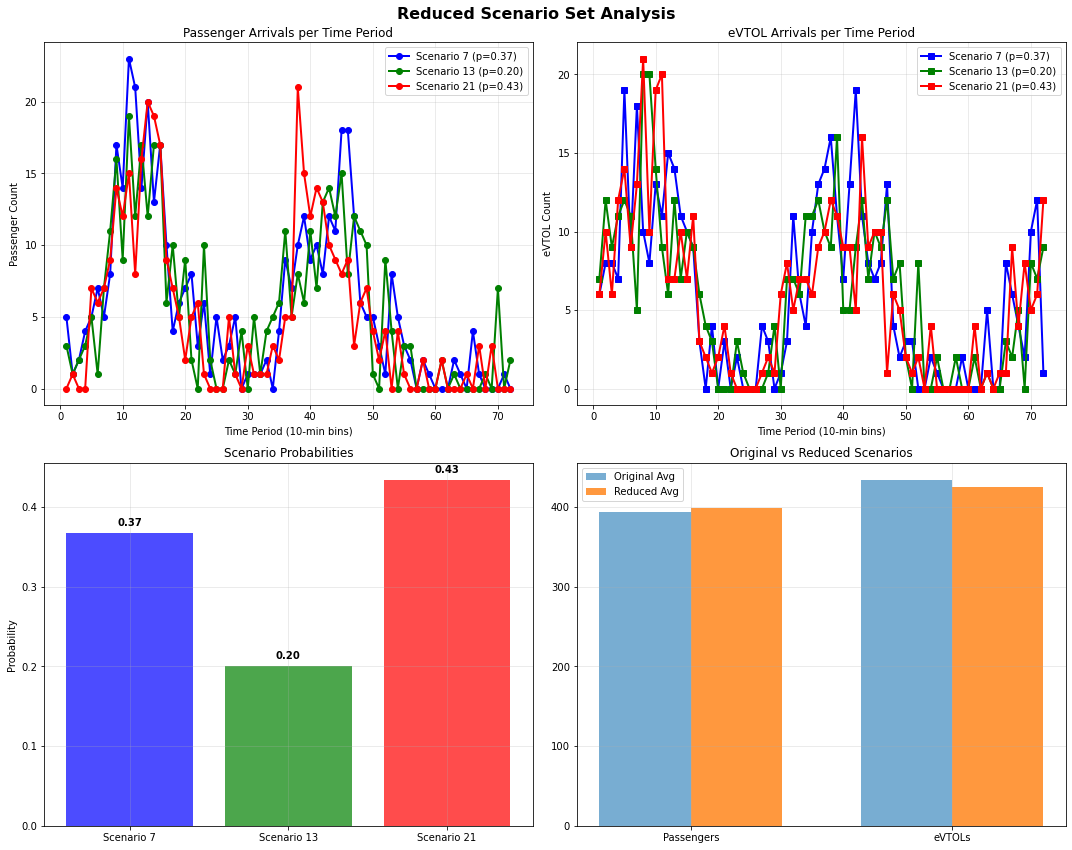

✅ Reduced to 3 representative scenarios.

 SCENARIO REDUCTION SUMMARY
Initial Scenarios: 30
Reduced to:        3 scenarios

Final Scenario Probabilities:
  Scenario 7   → p = 0.367
  Scenario 13  → p = 0.200
  Scenario 21  → p = 0.433

Average Total Passengers (Reduced): 399.00
Average Total eVTOLs (Reduced):    425.00
Average Empirical Correlation (Reduced): [N/A – not computed]
 Pipeline successfully completed for Case 2 (DFW Airport).



In [20]:
# ============================================================
#  Main Execution — Minimal eVTOL Simulation Pipeline + Reduction
# ============================================================
if __name__ == "__main__":
    """
    Full eVTOL simulation pipeline (clean version):
        1. Generate base vertiport scenario
        2. Simulate eVTOLs and passenger activity
        3. Build destination PMFs per time bin
        4. Generate 30 NHPP-based stochastic demand scenarios
        5. Apply backward scenario reduction (with eVTOL filtering)
        6. Output detailed reduction summary
    """

    # ------------------------------------------------------------
    #  Scenario Selection
    # ------------------------------------------------------------
    HUB_NAME = 'Dallas CBD' if FIXED_CASE == 1 else 'DFW Airport'
    TARGET_SCENARIOS = 3    # desired number of reduced representative scenarios

    print("\n" + "=" * 70)
    print(f" Starting eVTOL Simulation Pipeline — CASE {FIXED_CASE}: {HUB_NAME}")
    print("=" * 70)

    # ------------------------------------------------------------
    #  Step 1: Scenario Generation
    # ------------------------------------------------------------
    print("\n[1] Generating base vertiport scenario...")
    scenario = run_scenario(HUB_NAME, FIXED_CASE, plot=False, verbose=False)
    print("✅ Scenario generation complete.")

    # ------------------------------------------------------------
    #  Step 2: eVTOL and Passenger Simulation
    # ------------------------------------------------------------
    print("\n[2] Simulating eVTOL and passenger operations...")
    results = simulate_evtol_and_passengers(
        scenario_data=scenario,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        plot=False
    )
    print("✅ Simulation complete.")

    # ------------------------------------------------------------
    #  Step 3: Build Destination PMFs
    # ------------------------------------------------------------
    print("\n[3] Building destination PMFs per time bin...")
    pmfs, dests = build_bin_destination_pmfs(
        scenario["passenger_arrivals"],
        results["destinations"],
        scenario["assignment_shares"]
    )
    print(f"✅ PMFs built for {len(pmfs)} time bins.")

    # ------------------------------------------------------------
    #  Step 4: Generate NHPP-Based Demand Scenarios
    # ------------------------------------------------------------
    print("\n[4] Generating stochastic demand scenarios (NHPP-based)...")
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=scenario["passenger_arrivals"],
        evtol_arrivals=scenario["evtol_arrivals"],
        destination_data=scenario["destinations"],
        bin_pmfs=pmfs,
        n_scenarios=N_SCENARIOS,     # 30 total
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )
    print(f"✅ Generated {len(scenarios)} stochastic demand scenarios.")

    # ------------------------------------------------------------
    #  Step 5: Scenario Reduction
    # ------------------------------------------------------------
    print("\n[5] Performing backward scenario reduction with eVTOL filtering...")
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios,
        target_size=TARGET_SCENARIOS,
        plot=True
    )
    print(f"✅ Reduced to {len(reduced_scenarios)} representative scenarios.")

    # ------------------------------------------------------------
    #  Step 6: Summary Report
    # ------------------------------------------------------------
    print("\n" + "=" * 90)
    print(" SCENARIO REDUCTION SUMMARY")
    print("=" * 90)
    print(f"Initial Scenarios: {len(scenarios)}")
    print(f"Reduced to:        {len(reduced_scenarios)} scenarios\n")

    print("Final Scenario Probabilities:")
    for s in reduced_scenarios:
        print(f"  Scenario {s['id']+1:<3} → p = {s['probability']:.3f}")

    # Aggregate statistics
    avg_pass = np.mean([s['total_passengers'] for s in reduced_scenarios])
    avg_evtol = np.mean([s['total_evtols'] for s in reduced_scenarios])

    print("\nAverage Total Passengers (Reduced): "
          f"{avg_pass:.2f}")
    print("Average Total eVTOLs (Reduced):    "
          f"{avg_evtol:.2f}")

    if all('empirical_corr' in s for s in reduced_scenarios):
        avg_corr = np.mean([s['empirical_corr'] for s in reduced_scenarios])
        print(f"Average Empirical Correlation (Reduced): {avg_corr:.3f}")
    else:
        print("Average Empirical Correlation (Reduced): [N/A – not computed]")

    print("=" * 90)
    print(f" Pipeline successfully completed for Case {FIXED_CASE} ({HUB_NAME}).")
    print("=" * 90 + "\n")


## Conditional Sampling of State of Charge (SoC)

In [21]:
# ============================================================
#  Conditional SoC Sampling per eVTOL (Case-Aware, 6 AM–6 PM)
# ============================================================

def conditional_soc_sampling_per_evtol(
        reduced_scenarios,
        assignment_case=None,
        s_base=50,
        k=12,
        sigma_base=3,
        sigma_scale=5,
        plot=False):
    """
    Conditional SoC sampling for each eVTOL, case-aware (Dallas CBD or DFW Airport).

    Case 1 → Dallas CBD (Morning Peak): higher load earlier → lower SoC early
    Case 2 → DFW Airport (Evening Peak): higher load later → lower SoC later
    """

    case_label = {
        1: "Case 1 – Dallas CBD (Morning Peak)",
        2: "Case 2 – DFW Airport (Evening Peak)"
    }.get(assignment_case, "Unknown Case")

    # ------------------------------------------------------------
    # 1. Iterate through Reduced Scenarios
    # ------------------------------------------------------------
    for scenario in reduced_scenarios:
        a_t_omega = np.array(scenario['a_t'], dtype=float)
        e_t_omega = np.array(scenario['e_t'], dtype=float)

        # ------------------------------------------------------------
        # 2. Compute Load Ratios per Period (ρ_t_ω)
        # ------------------------------------------------------------
        rho_t_omega = np.divide(
            a_t_omega,
            np.maximum(e_t_omega, 1e-3),  # avoid division by zero
        )

        # smooth small gaps where eVTOL=0 using rolling interpolation
        for t in range(1, len(rho_t_omega)):
            if e_t_omega[t] == 0:
                rho_t_omega[t] = rho_t_omega[t-1]

        evtol_socs = {}
        evtol_arrival_periods = {}
        evtol_count = 0

        # ------------------------------------------------------------
        # 3. Adjust parameters by case
        # ------------------------------------------------------------
        if assignment_case == 1:   # Morning hub (Dallas CBD)
            s_base_adj = s_base + 2        # slightly higher base (early ops)
            k_adj = k                      # default slope
        elif assignment_case == 2: # Evening hub (DFW Airport)
            s_base_adj = s_base - 3        # slightly lower baseline (evening fatigue)
            k_adj = k * 1.1                # slightly steeper decline
        else:
            s_base_adj, k_adj = s_base, k

        # ------------------------------------------------------------
        # 4. Sample SoC for Each eVTOL
        # ------------------------------------------------------------
        for t in range(len(e_t_omega)):
            n_evtols = int(e_t_omega[t])
            if n_evtols <= 0:
                continue

            load_ratio = rho_t_omega[t]
            mu_s = s_base_adj - k_adj * load_ratio
            sigma_s = sigma_base + sigma_scale * load_ratio

            mu_s = np.clip(mu_s, 25, 55)
            sigma_s = np.clip(sigma_s, 2, 8)

            # Sample SoC values for all eVTOLs arriving at this period
            for _ in range(n_evtols):
                evtol_id = evtol_count
                evtol_arrival_periods[evtol_id] = t + 1
                # Re-sample until valid SoC is drawn
                soc_sample = None
                while soc_sample is None or not (20 <= soc_sample <= 60):
                    soc_sample = np.random.normal(mu_s, sigma_s)
                evtol_socs[evtol_id] = soc_sample
                evtol_count += 1

        # ------------------------------------------------------------
        # 5. Store Updated Scenario Data
        # ------------------------------------------------------------
        scenario['rho_t_omega'] = rho_t_omega
        scenario['evtol_socs'] = evtol_socs
        scenario['evtol_arrival_periods'] = evtol_arrival_periods
        scenario['total_evtols_count'] = evtol_count
        scenario['avg_load_ratio'] = np.mean(rho_t_omega)
        scenario['assignment_case'] = assignment_case

    # ------------------------------------------------------------
    # 6. Visualization (Optional)
    # ------------------------------------------------------------
    if plot:
        plt.figure(figsize=(12, 6))
        for s in reduced_scenarios:
            socs = list(s['evtol_socs'].values())
            plt.hist(socs, bins=8, alpha=0.6, edgecolor="black",
                     label=f"Scenario {s['id'] + 1}")
        plt.title(f"eVTOL State of Charge Distribution ({case_label}, 6 AM–6 PM)")
        plt.xlabel("State of Charge (%)")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    # ------------------------------------------------------------
    # 7. Return Updated Scenario Set
    # ------------------------------------------------------------
    return reduced_scenarios


In [22]:
# ============================================================
#  Main Execution — Full eVTOL Simulation Pipeline
# ============================================================
if __name__ == "__main__":
    """
    Full eVTOL simulation pipeline (enhanced version):
        1. Generate base vertiport scenario
        2. Simulate eVTOLs and passenger activity
        3. Build destination PMFs per time bin
        4. Generate NHPP-based stochastic demand scenarios
        5. Perform backward scenario reduction with eVTOL filter
        6. Perform conditional SoC sampling (case-aware)
        7. Print detailed summary reports
    """

    # ------------------------------------------------------------
    #  Scenario Selection
    # ------------------------------------------------------------
    HUB_NAME = 'Dallas CBD' if FIXED_CASE == 1 else 'DFW Airport'

    print("\n==========================")
    print(f"Running FIXED CASE {FIXED_CASE}: {HUB_NAME} Hub")
    print("==========================")

    # ------------------------------------------------------------
    #  Step 1: Scenario Generation
    # ------------------------------------------------------------
    scenario = run_scenario(HUB_NAME, FIXED_CASE, plot=False, verbose=False)

    # ------------------------------------------------------------
    #  Step 2: eVTOL and Passenger Simulation
    # ------------------------------------------------------------
    results = simulate_evtol_and_passengers(
        scenario_data=scenario,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        plot=False
    )

    # ------------------------------------------------------------
    #  Step 3: Build PMFs (Destination Probability per Time Bin)
    # ------------------------------------------------------------
    pmfs, dests = build_bin_destination_pmfs(
        scenario["passenger_arrivals"],
        results["destinations"],
        scenario["assignment_shares"]
    )

    # ------------------------------------------------------------
    #  Step 4: Generate Stochastic Demand Scenarios (NHPP)
    # ------------------------------------------------------------
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=scenario["passenger_arrivals"],
        evtol_arrivals=scenario["evtol_arrivals"],
        destination_data=scenario["destinations"],
        bin_pmfs=pmfs,
        n_scenarios=N_SCENARIOS,     # e.g., 30 total
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )

    # ------------------------------------------------------------
    #  Step 5: Scenario Reduction (Backward Selection + eVTOL Filter)
    # ------------------------------------------------------------
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios,
        target_size=TARGET_SCENARIOS,   # e.g., 3 representative cases
        plot=False
    )

    # ------------------------------------------------------------
    #  Step 6: Conditional SoC Sampling (Case-Aware)
    # ------------------------------------------------------------
    scenarios_with_soc = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_scenarios,
        s_base=50,
        k=12,
        sigma_base=3,
        sigma_scale=5,
        assignment_case=FIXED_CASE,   # Case 1 → morning bias; Case 2 → evening bias
        plot=False
    )

    # ------------------------------------------------------------
    #  Conditional SoC Summary Report
    # ------------------------------------------------------------
    print("\n" + "=" * 90)
    print(" CONDITIONAL STATE-OF-CHARGE (SoC) SAMPLING SUMMARY")
    print("=" * 90)
    print(f"Reduced Scenarios Evaluated: {len(scenarios_with_soc)}\n")

    for s in scenarios_with_soc:
        soc_values = list(s["evtol_socs"].values())
        print(f"Scenario {s['id'] + 1:>2}:")
        print(f"  • Total eVTOLs:       {s['total_evtols_count']}")
        print(f"  • Avg Load Ratio:     {s['avg_load_ratio']:.2f}")
        print(f"  • SoC Range:          {min(soc_values):.1f}% – {max(soc_values):.1f}%")
        print(f"  • Mean SoC:           {np.mean(soc_values):.1f}%")
        print(f"  • Std Dev (SoC):      {np.std(soc_values):.2f}\n")

    print("=" * 90)
    print(f"✅ Completed full pipeline for Case {FIXED_CASE} ({HUB_NAME}).")



Running FIXED CASE 2: DFW Airport Hub

 CONDITIONAL STATE-OF-CHARGE (SoC) SAMPLING SUMMARY
Reduced Scenarios Evaluated: 3

Scenario 15:
  • Total eVTOLs:       412
  • Avg Load Ratio:     1.44
  • SoC Range:          20.4% – 56.1%
  • Mean SoC:           36.8%
  • Std Dev (SoC):      8.39

Scenario 22:
  • Total eVTOLs:       444
  • Avg Load Ratio:     1.37
  • SoC Range:          20.6% – 54.7%
  • Mean SoC:           37.0%
  • Std Dev (SoC):      7.91

Scenario 24:
  • Total eVTOLs:       423
  • Avg Load Ratio:     1.33
  • SoC Range:          20.1% – 55.5%
  • Mean SoC:           36.6%
  • Std Dev (SoC):      8.27

✅ Completed full pipeline for Case 2 (DFW Airport).


## Input Data Preparation for Stochastic Optimization Model

In [23]:
# ============================================================
#  Build Stochastic Optimization Model Input 
# ============================================================

import random
import numpy as np
from collections import defaultdict

def build_stochastic_model_input(
    reduced_scenarios,
    bin_pmfs,                               # <-- NEW: per-bin destination PMFs (list[dict{name: p}])
    m_facilities=M_FACILITIES,
    l_periods=L_PERIODS,                    # should equal (HORIZON_END - HORIZON_START)//BIN_SIZE
    SoC_min=SOC_MIN,
    c=BATTERY_CAPACITY,
    qr=CHARGING_RATE,
    LoS=LOS,
    eVTOL_capacity=EVTOL_CAPACITY,
    destination_fares=None,                 # {dest_id:int -> fare:float}
    destination_mapping=None,               # {"id_to_name":{id->name}, "name_to_id":{name->id}}
    verbose=True
):
    """
    Build model-ready stochastic input using reduced scenarios (with SoC) and
    time-binned destination PMFs. Compatible with case-aware SoC sampling.
    """

    # --------------------------- 0) Validation ---------------------------
    if destination_fares is None:
        raise ValueError(" Missing required parameter: destination_fares")
    if not destination_mapping or "id_to_name" not in destination_mapping or "name_to_id" not in destination_mapping:
        raise ValueError(" destination_mapping must contain {'id_to_name', 'name_to_id'}")
    if not isinstance(bin_pmfs, (list, tuple)) or len(bin_pmfs) != l_periods:
        raise ValueError(f" bin_pmfs must be a list of length l_periods={l_periods}")

    id_to_name = destination_mapping["id_to_name"]
    name_to_id = destination_mapping["name_to_id"]

    # --------------------- 1) Master structure header --------------------
    stochastic_input = {
        "scenarios": {},
        "global_parameters": {
            "m_facilities": m_facilities,
            "l_periods": l_periods,
            "SoC_min": SoC_min,
            "c": c,
            "qr": qr,
            "LoS": LoS,
            "eVTOL_capacity": eVTOL_capacity,
            "destination_fares": destination_fares,
            "destination_mapping": destination_mapping,
            "horizon": {
                "start_min": HORIZON_START,
                "end_min": HORIZON_END,
                "bin_size_min": BIN_SIZE
            }
        }
    }

    # --------------------- 2) Scenario-specific packing ------------------
    for scenario in reduced_scenarios:
        sid = int(scenario["id"])
        prob = float(scenario["probability"])

        # Safety: number of time bins must match
        a_t = np.asarray(scenario["a_t"], dtype=int)
        e_t = np.asarray(scenario["e_t"], dtype=int)
        if len(a_t) != l_periods or len(e_t) != l_periods:
            raise ValueError(f" Scenario {sid}: time series length mismatch with l_periods={l_periods}")

        # eVTOL counts / passengers (weights)
        n_evtols = int(scenario.get("total_evtols_count", e_t.sum()))
        w_passengers = int(a_t.sum())

        scenario_data = {
            "probability": prob,
            "n_evtols": n_evtols,
            "w_passengers": w_passengers,
            "evtols": {},                # j -> {arrival_time, arrival_bin, soc, charging_periods, finish_charging_period, charging_cost}
            "agg_pass_demand": {}        # (t_bin, dest_id) -> count
        }

        # -------- 2.1 eVTOL Arrivals & Charging using SoC samples --------
        # Prefer exact arrival bins from conditional sampling, else reconstruct from e_t
        evtol_arrival_bins = []
        if "evtol_arrival_periods" in scenario and scenario["evtol_arrival_periods"]:
            # Provided as 1-based bins
            ordered = sorted(scenario["evtol_arrival_periods"].items(), key=lambda kv: kv[0])  # by evtol_id
            evtol_arrival_bins = [int(b) for _, b in ordered]
        else:
            # Expand e_t into a list of 1-based arrival bins
            for t_bin, cnt in enumerate(e_t, start=1):
                evtol_arrival_bins.extend([t_bin] * int(cnt))

        # SoC values (already case-aware from previous step); fallback if missing
        soc_dict = scenario.get("evtol_socs", {})
        soc_values = [float(soc_dict.get(j, random.uniform(20, 60))) for j in range(len(evtol_arrival_bins))]

        # Convert bins to arrival times (uniform within the bin window)
        evtol_arrival_times = []
        for b in evtol_arrival_bins:
            start_min = HORIZON_START + (b - 1) * BIN_SIZE
            evtol_arrival_times.append(start_min + random.uniform(0, BIN_SIZE))

        # Compute charging details & TOU cost
        for j, (arrival_bin, arrival_time, soc) in enumerate(zip(evtol_arrival_bins, evtol_arrival_times, soc_values)):
            if soc < SoC_min:
                charge_needed_kWh = c * ((SoC_min - soc) / 100.0)
                hours_to_charge = charge_needed_kWh / qr
                periods_to_charge = hours_to_charge * (60.0 / BIN_SIZE)
                p_j = int(np.ceil(periods_to_charge))
                # Sum TOU price across periods
                total_cost = 0.0
                current_minute = arrival_time
                for _ in range(p_j):
                    current_hour = (current_minute % 1440) / 60.0
                    energy_this_period = qr / (60.0 / BIN_SIZE)  # kWh charged in one BIN
                    total_cost += energy_this_period * energy_price_per_kWh(current_hour)
                    current_minute += BIN_SIZE
                finish_period = min(arrival_bin + p_j, l_periods)
            else:
                p_j, finish_period, total_cost = 0, arrival_bin, 0.0

            scenario_data["evtols"][j] = {
                "arrival_time": arrival_time,
                "arrival_bin": arrival_bin,
                "soc": soc,
                "charging_periods": p_j,
                "finish_charging_period": finish_period,
                "charging_cost": total_cost
            }

        # -------- 2.2 Aggregate Passenger Demand via PMFs (time × dest) --------
        agg_pass_demand = defaultdict(int)
        # Precompute PMFs over destination **IDs** per bin
        # bin_pmfs[t] is {dest_name: p}; map to ids and ensure normalization
        pmf_ids = []
        for t in range(l_periods):
            pmf_t = bin_pmfs[t]
            # keep only destinations we know about (present in mapping)
            names, probs = zip(*[(nm, pmf_t[nm]) for nm in pmf_t if nm in name_to_id]) if pmf_t else ([], [])
            if names:
                ids = [name_to_id[nm] for nm in names]
                probs = np.array(probs, dtype=float)
                s = probs.sum()
                if s <= 0:
                    # fallback to uniform over known ids if something degenerate happens
                    probs = np.ones(len(ids), dtype=float) / len(ids)
                else:
                    probs = probs / s
                pmf_ids.append((ids, probs))
            else:
                # fallback: uniform over all destinations we have fares for
                ids = list(destination_fares.keys())
                probs = np.ones(len(ids), dtype=float) / max(1, len(ids))
                pmf_ids.append((ids, probs))

        # Sample destinations for each passenger arrival using the per-bin PMFs
        for t_bin, count in enumerate(a_t, start=1):
            if count <= 0:
                continue
            ids, probs = pmf_ids[t_bin - 1]
            draws = np.random.choice(ids, size=int(count), p=probs)
            for d in draws:
                agg_pass_demand[(t_bin, int(d))] += 1

        # Ensure every (t, d) pair exists (even if zero)
        for t_bin in range(1, l_periods + 1):
            for d in destination_fares.keys():
                agg_pass_demand.setdefault((t_bin, int(d)), 0)

        scenario_data["agg_pass_demand"] = dict(agg_pass_demand)
        stochastic_input["scenarios"][sid] = scenario_data

    # ------------------------- 3) Global ranges --------------------------
    all_evtols = [s["n_evtols"] for s in stochastic_input["scenarios"].values()]
    all_passengers = [s["w_passengers"] for s in stochastic_input["scenarios"].values()]
    stochastic_input["global_parameters"]["n_evtols_range"] = (int(min(all_evtols)), int(max(all_evtols)))
    stochastic_input["global_parameters"]["w_passengers_range"] = (int(min(all_passengers)), int(max(all_passengers)))

    # ------------------------ 4) Verbose summary -------------------------
    if verbose:
        print("=" * 90)
        print(" STOCHASTIC MODEL INPUT SUMMARY")
        print("=" * 90)
        print(f"Scenarios packed: {len(stochastic_input['scenarios'])}")
        print(f"Horizon: {HORIZON_START}–{HORIZON_END} min "
              f"({l_periods} periods × {BIN_SIZE}-min bins)\n")

        for sid, data in stochastic_input["scenarios"].items():
            print(f"Scenario {sid:2d} (p={data['probability']:.3f}):")
            print(f"  - eVTOLs:     {data['n_evtols']}")
            print(f"  - Passengers: {data['w_passengers']}")
            if data["evtols"]:
                print("  - eVTOL Details (first 8):")
                for eid, e in list(data["evtols"].items())[:8]:
                    print(f"      eVTOL {eid:3d}: Bin={e['arrival_bin']:3d}, "
                          f"Charge={e['charging_periods']:2d}p, "
                          f"SoC={e['soc']:5.1f}%, "
                          f"Cost=${e['charging_cost']:6.2f}")
            if data["agg_pass_demand"]:
                print("  - Demand (first 10 time–destination pairs):")
                shown = 0
                for (t, d), cnt in data["agg_pass_demand"].items():
                    if shown >= 10:
                        break
                    print(f"      Time {t:2d} → Dest {d:2d} ({id_to_name.get(d, 'Unknown'):<28}) : {cnt:3d}")
                    shown += 1
            print("-" * 80)

        print(f"\nRange of eVTOLs:     {min(all_evtols)}–{max(all_evtols)}")
        print(f"Range of Passengers: {min(all_passengers)}–{max(all_passengers)}")
        print("=" * 90)

    return stochastic_input


In [24]:
# ============================================================
#  Main Execution — Full eVTOL Simulation + Stochastic Input Pipeline
# ============================================================

if __name__ == "__main__":
    """
    Full pipeline sequence:
        1. Generate base vertiport scenario
        2. Simulate eVTOL & passenger arrivals
        3. Build PMFs for destination probabilities
        4. Generate stochastic demand scenarios
        5. Perform backward scenario reduction
        6. Perform conditional SoC sampling (case-aware)
        7. Build stochastic model input (optimization-ready)
        8. Print summary reports
    """

    # ------------------------------------------------------------
    # CASE SELECTION
    # ------------------------------------------------------------
    HUB_NAME = 'Dallas CBD' if FIXED_CASE == 1 else 'DFW Airport'

    print("\n==============================")
    print(f" Running Case {FIXED_CASE}: {HUB_NAME}")
    print("==============================")

    # ------------------------------------------------------------
    # STEP 1 — Scenario Generation
    # ------------------------------------------------------------
    scenario = run_scenario(HUB_NAME, FIXED_CASE, plot=False, verbose=False)

    # ------------------------------------------------------------
    # STEP 2 — eVTOL & Passenger Simulation
    # ------------------------------------------------------------
    results = simulate_evtol_and_passengers(
        scenario_data=scenario,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        plot=False
    )

    # ------------------------------------------------------------
    # STEP 3 — Build Destination PMFs (per time bin)
    # ------------------------------------------------------------
    pmfs, dests = build_bin_destination_pmfs(
        scenario["passenger_arrivals"],
        results["destinations"],
        scenario["assignment_shares"]
    )

    # ------------------------------------------------------------
    # STEP 4 — Generate NHPP-Based Demand Scenarios
    # ------------------------------------------------------------
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=scenario["passenger_arrivals"],
        evtol_arrivals=scenario["evtol_arrivals"],
        destination_data=scenario["destinations"],
        bin_pmfs=pmfs,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )

    # ------------------------------------------------------------
    # STEP 5 — Scenario Reduction
    # ------------------------------------------------------------
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios,
        target_size=TARGET_SCENARIOS,
        plot=False
    )

    # ------------------------------------------------------------
    # STEP 6 — Conditional SoC Sampling (Case-Aware)
    # ------------------------------------------------------------
    scenarios_with_soc = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_scenarios,
        s_base=50,
        k=12,
        sigma_base=3,
        sigma_scale=5,
        assignment_case=FIXED_CASE,
        plot=False
    )

    # ------------------------------------------------------------
    # STEP 7 — Build Stochastic Optimization Input
    # ------------------------------------------------------------
    # Prepare mapping and fare dictionary
    destination_mapping = {
        "id_to_name": scenario["destination_map"],
        "name_to_id": scenario["name_to_number"]
    }
    destination_fares = {
        destination_mapping["name_to_id"][name]: data["fare"]
        for name, data in scenario["destinations"].items()
    }

    stochastic_input = build_stochastic_model_input(
        reduced_scenarios=scenarios_with_soc,
        bin_pmfs=pmfs,
        destination_fares=destination_fares,
        destination_mapping=destination_mapping,
        verbose=True
    )

    # ------------------------------------------------------------
    # STEP 8 — Summary Reports
    # ------------------------------------------------------------

    # 8.1 Stochastic Input Summary (high-level)
    gp = stochastic_input["global_parameters"]
    print("\n" + "=" * 90)
    print("🧮 STOCHASTIC MODEL INPUT SUMMARY (GLOBAL)")
    print("=" * 90)
    print(f"Facilities:       {gp['m_facilities']}")
    print(f"Periods:          {gp['l_periods']} × {gp['horizon']['bin_size_min']} min")
    print(f"SoC_min:          {gp['SoC_min']}%")
    print(f"Charging Rate:    {gp['qr']} kW")
    print(f"LoS Limit:        {gp['LoS']} periods")
    print(f"Destinations:     {len(gp['destination_fares'])}")
    print(f"Scenario Range eVTOLs: {gp['n_evtols_range']}")
    print(f"Scenario Range Pax:    {gp['w_passengers_range']}")
    print("=" * 90)

    print(f"✅ Completed full pipeline for Case {FIXED_CASE} ({HUB_NAME}).\n")



 Running Case 2: DFW Airport
 STOCHASTIC MODEL INPUT SUMMARY
Scenarios packed: 3
Horizon: 360–1080 min (72 periods × 10-min bins)

Scenario  7 (p=0.433):
  - eVTOLs:     443
  - Passengers: 379
  - eVTOL Details (first 8):
      eVTOL   0: Bin=  1, Charge= 3p, SoC= 37.4%, Cost=$  9.73
      eVTOL   1: Bin=  1, Charge= 3p, SoC= 33.3%, Cost=$  9.73
      eVTOL   2: Bin=  1, Charge= 3p, SoC= 42.1%, Cost=$  9.73
      eVTOL   3: Bin=  1, Charge= 3p, SoC= 35.4%, Cost=$  9.73
      eVTOL   4: Bin=  1, Charge= 2p, SoC= 51.6%, Cost=$  6.48
      eVTOL   5: Bin=  1, Charge= 2p, SoC= 44.9%, Cost=$  6.48
      eVTOL   6: Bin=  1, Charge= 2p, SoC= 48.6%, Cost=$  6.48
      eVTOL   7: Bin=  2, Charge= 3p, SoC= 40.8%, Cost=$  9.73
  - Demand (first 10 time–destination pairs):
      Time  1 → Dest  5 (Dallas Executive Airport (RBD)) :   1
      Time  1 → Dest  1 (Dallas CBD                  ) :   1
      Time  2 → Dest  6 (Denton Municipal Airport    ) :   1
      Time  3 → Dest  3 (Fort Worth City 

## Stochastic Optimization Model Fourmulation

In [25]:
# ============================================================
#  STOCHASTIC eVTOL SCHEDULING MODEL (GUROBI)
# ============================================================

import gurobipy as grb


def build_and_solve_stochastic_model_aggregated(
    stochastic_input,
    M=1000,
    verbose=True,
):
    """
    Build and solve a **stochastic aggregated eVTOL scheduling model** using Gurobi.

    The model optimizes eVTOL charging assignments, passenger service allocation,
    and revenue–cost tradeoffs across multiple stochastic demand scenarios.

    Steps:
        1. Extract global data and indices
        2. Define decision variables (charging, assignment, service)
        3. Add logical and operational constraints
        4. Define revenue, charging, and penalty components
        5. Maximize expected profit
        6. Solve and report results

    Parameters
    ----------
    stochastic_input : dict
        Structured data from `build_stochastic_model_input()`.
    M : float, default=1000
        Big-M constant for logical linking constraints.
    verbose : bool, default=True
        Toggle solver output.
    Returns
    -------
    model : gurobipy.Model
        The optimized Gurobi model.
    results : dict
        Summary of optimization outcomes.
    """

    # =====================================================
    #  Extract Global Parameters and Sets
    # =====================================================
    global_params = stochastic_input["global_parameters"]
    m_facilities = global_params["m_facilities"]
    l_periods = global_params["l_periods"]
    eVTOL_capacity = global_params["eVTOL_capacity"]
    LoS = global_params["LoS"]
    destination_fares = global_params["destination_fares"]

    I = list(range(m_facilities))        # Facilities
    Time = list(range(1, l_periods + 1)) # Time bins
    S = list(stochastic_input["scenarios"].keys())  # Scenarios
    D = list(destination_fares.keys())   # Destinations

    # =====================================================
    #  Initialize Model
    # =====================================================
    model = grb.Model("Stochastic_eVTOL_Scheduling")
    if not verbose:
        model.Params.OutputFlag = 0
    model.Params.MIPGap = 0.05
    model.Params.TimeLimit = 300
    model.Params.DualReductions = 0

    # =====================================================
    #  Decision Variables
    # =====================================================
    x, C, F, z, pass_assigned, unserved_pass, Y, Tvar, use_evtol = {}, {}, {}, {}, {}, {}, {}, {}, {}

    for s in S:
        scenario = stochastic_input["scenarios"][s]
        n_evtols = scenario["n_evtols"]
        J = list(range(n_evtols))

        # eVTOL activation
        for j in J:
            use_evtol[j, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"use_{j}_{s}")

        # Charging assignment: x[i,j,t,s]
        for i in I:
            for j in J:
                for t in Time:
                    x[i, j, t, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"x_{i}_{j}_{t}_{s}")

        # Completion & takeoff times
        for j in J:
            C[j, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"C_{j}_{s}")
            F[j, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"F_{j}_{s}")

            for d in D:
                z[j, d, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"z_{j}_{d}_{s}")

            for t in Time:
                for d in D:
                    pass_assigned[j, t, d, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"pass_{j}_{t}_{d}_{s}")
                    Y[j, t, d, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"Y_{j}_{t}_{d}_{s}")
                    Tvar[j, t, d, s] = model.addVar(lb=0, vtype=grb.GRB.CONTINUOUS, name=f"T_{j}_{t}_{d}_{s}")

        # Unserved passengers
        for t in Time:
            for d in D:
                unserved_pass[t, d, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"unserved_{t}_{d}_{s}")

    model.update()

    # =====================================================
    #  Constraints (Scenario-specific)
    # =====================================================
    for s in S:
        scenario = stochastic_input["scenarios"][s]
        n_evtols = scenario["n_evtols"]
        J = list(range(n_evtols))

        r = {j: scenario["evtols"][j]["arrival_bin"] for j in J}
        p = {j: scenario["evtols"][j]["charging_periods"] for j in J}
        charging_cost = {j: scenario["evtols"][j]["charging_cost"] for j in J}
        agg_pass_demand = scenario["agg_pass_demand"]

        # (1) Feasible charging assignment or deactivation
        for j in J:
            start, end = r[j], l_periods - p[j] + 1
            if start <= end:
                model.addConstr(grb.quicksum(x[i, j, t, s] for i in I for t in range(start, end + 1)) == use_evtol[j, s])
            else:
                model.addConstr(use_evtol[j, s] == 0)
                for i in I:
                    for t in Time:
                        model.addConstr(x[i, j, t, s] == 0)

        # (2) Facility capacity: one eVTOL per facility per period
        for i in I:
            for t in Time:
                model.addConstr(
                    grb.quicksum(x[i, j, u, s] for j in J for u in range(max(1, t - p[j] + 1), t + 1) if u >= r[j]) <= 1
                )

        # (3) Completion and takeoff
        for j in J:
            model.addConstr(C[j, s] == grb.quicksum((t + p[j] - 1) * x[i, j, t, s] for i in I for t in Time))
            model.addConstr(F[j, s] >= C[j, s])

        # (4) Destination and capacity linkage
        for j in J:
            model.addConstr(grb.quicksum(z[j, d, s] for d in D) <= use_evtol[j, s])
            model.addConstr(grb.quicksum(pass_assigned[j, t, d, s] for t in Time for d in D)
                            <= eVTOL_capacity * use_evtol[j, s])

        # (5) Link passengers → Y and Y → destination
        for j in J:
            for t in Time:
                for d in D:
                    model.addConstr(pass_assigned[j, t, d, s] <= eVTOL_capacity * Y[j, t, d, s])
            for d in D:
                model.addConstr(grb.quicksum(Y[j, t, d, s] for t in Time) <= M * z[j, d, s])

        # (6) Demand balance
        for t in Time:
            for d in D:
                model.addConstr(
                    grb.quicksum(pass_assigned[j, t, d, s] for j in J) + unserved_pass[t, d, s] == agg_pass_demand[t, d]
                )

        # (7) Level of Service (tardiness bounds)
        for j in J:
            for t in Time:
                for d in D:
                    model.addConstr(Tvar[j, t, d, s] >= F[j, s] - t - M * (1 - Y[j, t, d, s]))
                    model.addConstr(Tvar[j, t, d, s] <= LoS + M * (1 - Y[j, t, d, s]))
                    model.addConstr(Tvar[j, t, d, s] >= 0)

    # =====================================================
    #  Objective Function (Expected Profit)
    # =====================================================
    total_revenue, total_costs, total_penalty = 0, 0, 0

    for s in S:
        scenario = stochastic_input["scenarios"][s]
        prob = scenario["probability"]
        n_evtols = scenario["n_evtols"]
        J = list(range(n_evtols))
        charging_cost = {j: scenario["evtols"][j]["charging_cost"] for j in J}

        revenue = grb.quicksum(
            pass_assigned[j, t, d, s] * destination_fares[d]
            for j in J for t in Time for d in D
        )
        charge_cost = grb.quicksum(
            charging_cost[j] * grb.quicksum(x[i, j, t, s] for i in I for t in Time)
            for j in J
        )
        penalty = grb.quicksum(destination_fares[d] * unserved_pass[t, d, s] for t in Time for d in D)

        total_revenue += prob * revenue
        total_costs += prob * charge_cost
        total_penalty += prob * penalty

    model.setObjective(total_revenue - total_costs - total_penalty, grb.GRB.MAXIMIZE)

    # =====================================================
    #  Solve Model
    # =====================================================
    print("\n Solving stochastic scheduling model...")
    model.optimize()

    # =====================================================
    #  Status Reporting
    # =====================================================
    if model.Status == grb.GRB.OPTIMAL:
        print("✅ Optimal solution found.")
        print(f"   Objective Value: ${model.ObjVal:,.2f}")
    elif model.Status == grb.GRB.INFEASIBLE:
        print("❌ Model infeasible. Writing IIS to 'inf.ilp' ...")
        model.computeIIS()
        model.write("inf.ilp")
    elif model.Status == grb.GRB.UNBOUNDED:
        print(" Model unbounded.")
    elif model.Status == grb.GRB.INF_OR_UNBD:
        print(" Model infeasible or unbounded.")
    else:
        print(f" Optimization ended with status code {model.Status}.")

    # =====================================================
    #  Scenario-Wise Detailed Reporting
    # =====================================================
    if model.Status == grb.GRB.OPTIMAL:
        print("\n DETAILED RESULTS PER SCENARIO\n")
        for s in S:
            scenario = stochastic_input["scenarios"][s]
            prob = scenario["probability"]
            J = list(scenario["evtols"].keys())
            charging_cost = {j: scenario["evtols"][j]["charging_cost"] for j in J}

            served = sum(pass_assigned[j, t, d, s].X for j in J for t in Time for d in D)
            unserved = sum(unserved_pass[t, d, s].X for t in Time for d in D)
            revenue = sum(pass_assigned[j, t, d, s].X * destination_fares[d] for j in J for t in Time for d in D)
            lost = sum(unserved_pass[t, d, s].X * destination_fares[d] for t in Time for d in D)
            charge = sum(charging_cost[j] * sum(x[i, j, t, s].X for i in I for t in Time) for j in J)
            net = revenue - lost - charge

            print(f" Scenario {s} (p={prob:.2f}) → Served={served}, Unserved={unserved}, Net=${net:,.2f}")

    # =====================================================
    #  Return Results
    # =====================================================
    return model, {
        "status": model.Status,
        "objective": model.ObjVal if model.SolCount > 0 else None
    }


# Main Code

In [26]:
# ============================================================
#  Main Execution — Full eVTOL Simulation + Stochastic Input Pipeline
# ============================================================

if __name__ == "__main__":
    """
    Full pipeline sequence:
        1. Generate base vertiport scenario
        2. Simulate eVTOL & passenger arrivals
        3. Build PMFs for destination probabilities
        4. Generate stochastic demand scenarios
        5. Perform backward scenario reduction
        6. Perform conditional SoC sampling (case-aware)
        7. Build stochastic model input (optimization-ready)
        8. Solve stochastic optimization model
        9. Summary output
    """

    # ------------------------------------------------------------
    # CASE SELECTION
    # ------------------------------------------------------------
    HUB_NAME = 'Dallas CBD' if FIXED_CASE == 1 else 'DFW Airport'

    print("\n==============================")
    print(f" Running Case {FIXED_CASE}: {HUB_NAME}")
    print("==============================")

    # ------------------------------------------------------------
    # STEP 1 — Scenario Generation
    # ------------------------------------------------------------
    scenario = run_scenario(HUB_NAME, FIXED_CASE, plot=False, verbose=False)

    # ------------------------------------------------------------
    # STEP 2 — eVTOL & Passenger Simulation
    # ------------------------------------------------------------
    results = simulate_evtol_and_passengers(
        scenario_data=scenario,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        plot=False
    )

    # ------------------------------------------------------------
    # STEP 3 — Build Destination PMFs (per time bin)
    # ------------------------------------------------------------
    pmfs, dests = build_bin_destination_pmfs(
        scenario["passenger_arrivals"],
        results["destinations"],
        scenario["assignment_shares"]
    )

    # ------------------------------------------------------------
    # STEP 4 — Generate NHPP-Based Demand Scenarios
    # ------------------------------------------------------------
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=scenario["passenger_arrivals"],
        evtol_arrivals=scenario["evtol_arrivals"],
        destination_data=scenario["destinations"],
        bin_pmfs=pmfs,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )

    # ------------------------------------------------------------
    # STEP 5 — Scenario Reduction
    # ------------------------------------------------------------
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios,
        target_size=TARGET_SCENARIOS,
        plot=False
    )

    # ------------------------------------------------------------
    # STEP 6 — Conditional SoC Sampling (Case-Aware)
    # ------------------------------------------------------------
    scenarios_with_soc = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_scenarios,
        s_base=50,
        k=12,
        sigma_base=3,
        sigma_scale=5,
        assignment_case=FIXED_CASE,
        plot=False
    )

    # ------------------------------------------------------------
    # STEP 7 — Build Stochastic Optimization Input
    # ------------------------------------------------------------
    destination_mapping = {
        "id_to_name": scenario["destination_map"],
        "name_to_id": scenario["name_to_number"]
    }
    destination_fares = {
        destination_mapping["name_to_id"][name]: data["fare"]
        for name, data in scenario["destinations"].items()
    }

    stochastic_input = build_stochastic_model_input(
        reduced_scenarios=scenarios_with_soc,
        bin_pmfs=pmfs,
        destination_fares=destination_fares,
        destination_mapping=destination_mapping,
        verbose=False
    )

    # ------------------------------------------------------------
    # STEP 8 — Build and Solve the Stochastic Optimization Model
    # ------------------------------------------------------------
    print("\n Running Stochastic Optimization Model (Gurobi)...")

    model, results = build_and_solve_stochastic_model_aggregated(
        stochastic_input=stochastic_input,
        M=1000,
        verbose=True,
    )

    # ============================================================
    # 9️⃣ Summary Output
    # ============================================================
    print("\n" + "=" * 100)
    print(" FULL STOCHASTIC PIPELINE COMPLETED SUCCESSFULLY ✅")
    if results["objective"]:
        print(f"Final Objective Value: ${results['objective']:,.2f}")
    print("=" * 100)



 Running Case 2: DFW Airport

 Running Stochastic Optimization Model (Gurobi)...
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 300
Set parameter DualReductions to value 0

 Solving stochastic scheduling model...
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-6700HQ CPU @ 2.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads



GurobiError: Model too large for size-limited license; visit https://gurobi.com/unrestricted for more information